In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon')
sys.path.insert(0, r'Z:\Users\Gregory\Ca40_multi_photon\raman_simulation')
import useful_funcs
import simulation as s
from scipy.optimize import curve_fit

cb_d = (106/255, 139/255,239/255)
cb_l = (158/255, 190/255,255/255)
cr_d = (214/255, 82/255,68/255)
cr_l = (244/255, 152/255,122/255)

In [2]:
sim_two_photon = s.sim(ls_854 = 2*np.pi*.5e6)
sim_two_photon.carrier = True
sim_two_photon.counter_rot = True
sim_two_photon.F_states = True
sim_two_photon.get_f()

sim_four_photon = s.sim()
sim_four_photon.counter_rot = True
sim_four_photon.F_states = True
sim_four_photon.get_f()

sim_d52 = s.sim()
sim_d52.counter_rot = True
sim_d52.F_states = True
sim_d52.ls_order = 4
sim_d52.get_f()

In [3]:
# fit function for D5/2 splittings
def get_splittings(x, w0r, r_sp, r_pi):
    sim_d52.w0r = w0r
    sim_d52.r_sp = r_sp
    sim_d52.r_pi = r_pi
    sim_d52.Pb = 0
    
    Pr_bank = np.array([0.100, 0.195])
    sim_d52.rsig_splittings(Pr_bank)
    # sim_d52.ω = 0
    y = np.concatenate((sim_d52.w01, sim_d52.w12, sim_d52.w23, sim_d52.w34, sim_d52.w45))/(2*np.pi*1e3)

    return y

# fit function for two photon powerscaling numerics
def power_scaling_numeric_two(Pb, w0r, r_sp, r_pi, w0b, ϕ):
    #rsig
    sim_two_photon.Pr = 0.195
    sim_two_photon.w0r = w0r
    sim_two_photon.r_sp = r_sp
    sim_two_photon.r_pi = r_pi
    # rpi
    sim_two_photon.w0b = w0b
    sim_two_photon.ϕ = ϕ
    sim_two_photon.b_sp = .3355
    sim_two_photon.b_pi = 0.329

    sim_two_photon.ls_854 = 2*np.pi*.5e6
    
    sim_two_photon.power_scaling(Pb)
    
    return np.abs(sim_two_photon.Ω_num_bank/(2*np.pi*1e3))

# fit function for four-photon analytics including six-photon corrections
def power_scaling_analytic_four(Pb, w0r, r_sp, r_pi, w0b, ϕ):
    #rsig
    sim_four_photon.Pr = 0.195
    sim_four_photon.w0r = w0r
    sim_four_photon.r_sp = r_sp
    sim_four_photon.r_pi = r_pi
    # rpi
    sim_four_photon.w0b = w0b
    sim_four_photon.ϕ = ϕ
    sim_four_photon.b_sp = .3355
    sim_four_photon.b_pi = 0.329
    
    sim_four_photon.get_rabi_frequencies()
    sim_four_photon.analytics(Pb, sim_resonance = 2*np.pi*sim_four_photon.res_4)
    
    return np.abs(-sim_four_photon.Ω03_4 - sim_four_photon.Ω03_6)/(2*np.pi*1e3)

In [4]:
def joint_function_numeric(x, w0r, r_sp, r_pi, w0b, ϕ):
    y1 = power_scaling_numeric_two(x, w0r, r_sp, r_pi, w0b, ϕ)
    y2 = get_splittings(x, w0r, r_sp, r_pi)
    y3 = power_scaling_analytic_four(x, w0r, r_sp, r_pi, w0b, ϕ)
    return np.concatenate((y1, y2, y2, y2, y3))

def fit_joint_function_numeric(x_data, y_data, y_error, p0):
    bounds = ((28e-6, .05, 1e-4, 30e-6, -.01),(33e-6, .1, 6e-2, 36e-6, 2*np.pi))
    popt, pcov = curve_fit(joint_function_numeric, x_data, y_data, p0 = p0, bounds = bounds, sigma = y_error)
    error = np.sqrt(np.diag(pcov))
    return popt, error, pcov

In [5]:
p0 = [31.51e-6, .0755, .0016, 32.2e-6, 1.0*2*np.pi]

In [6]:
x_data = sim_d52.RID_rpi*1e-3
y_data = np.concatenate(((np.pi/sim_d52.tpi_2)/(2*np.pi*1e3), sim_d52.d52_splittings*1e3, sim_d52.d52_splittings*1e3, sim_d52.d52_splittings*1e3, (np.pi/sim_d52.tpi_4)/(2*np.pi*1e3)))
δres = sim_d52.δd52_splittings
y_error = np.concatenate(((np.pi*sim_d52.δtpi_2/sim_d52.tpi_2**2)/(2*np.pi*1e3),δres*1e3,δres*1e3,δres*1e3, (np.pi*sim_d52.δtpi_4/sim_d52.tpi_4**2)/(2*np.pi*1e3)))

In [ ]:
p, error, pcov = fit_joint_function_numeric(x_data, y_data, y_error, p0)

power scan progress:   0%|          | 0/24 [00:00<?, ?it/s]

spectroscopy, Pb = 180.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 152.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 130.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 112.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

...

spectroscopy, Pb = 45.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 41.5 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 38.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 34.5 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 32.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

In [18]:
p

array([3.15912891e-05, 7.44879072e-02, 1.00000000e-04, 3.00670078e-05,
       6.28318530e+00])

In [7]:
params = np.array([31.51722131006443*1e-6, 0.07554338311557529, 0.0015936239200809305, 30.00092487180367*1e-6, 6.282981751066775])

In [21]:
x = sim_d52.RID_rpi*1e-3
y = joint_function_numeric(x, *p)

power scan progress:   0%|          | 0/24 [00:00<?, ?it/s]

spectroscopy, Pb = 180.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 152.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 130.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 112.0 mW:   0%|          | 0/40 [00:00<?, ?it/s]

...

spectroscopy, Pb = 24.3 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 22.8 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 21.4 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 19.9 mW:   0%|          | 0/40 [00:00<?, ?it/s]

spectroscopy, Pb = 18.8 mW:   0%|          | 0/40 [00:00<?, ?it/s]

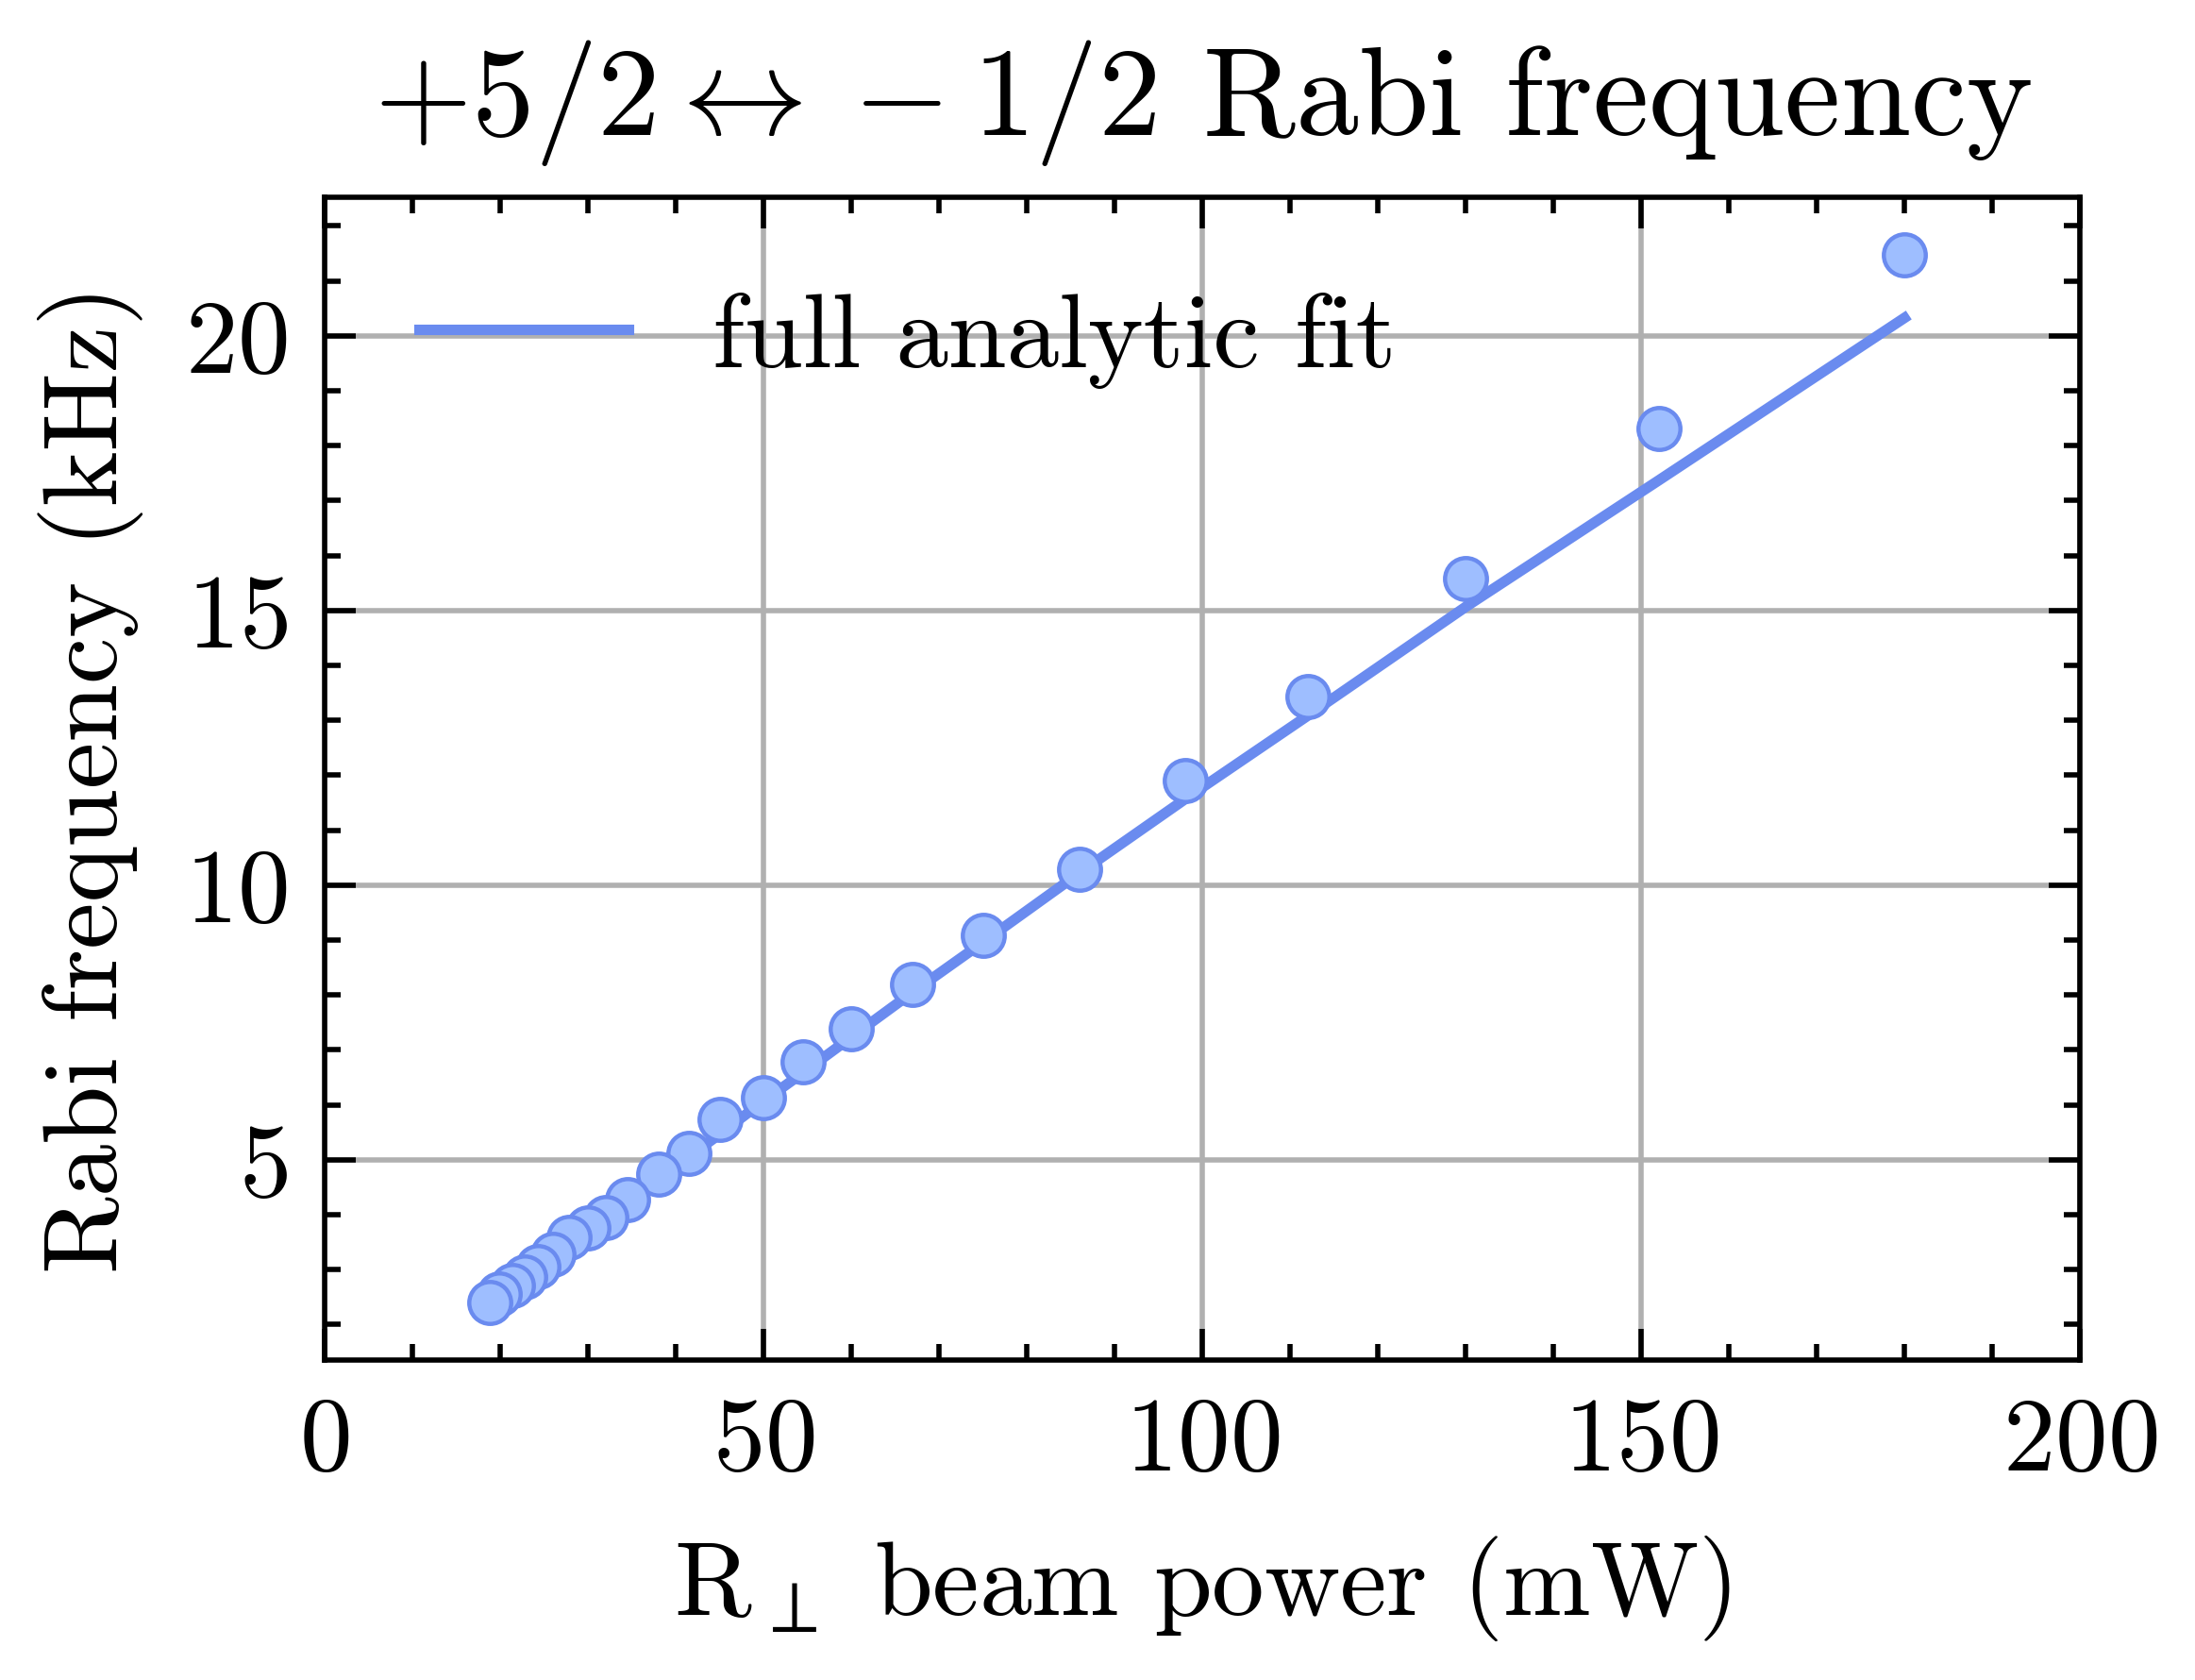

In [22]:
with plt.style.context(['science','no-latex']):
    plt.figure(dpi = 800, figsize = (3,2))

    # plt.errorbar(x_data*1e3,(np.pi/sim_d52.tpi_4)/(2*np.pi*1e3), 
    #              (np.pi*sim_d52.δtpi_4/sim_d52.tpi_4**2)/(2*np.pi*1e3), marker = '.' , ls = 'none', ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .4, 
    #              markersize=5, capsize=1, elinewidth = .5,markerfacecolor='gray', label = 'experiment', alpha = 1)
    plt.errorbar(x_data*1e3,(np.pi/sim_d52.tpi_4)/(2*np.pi*1e3), 
                 (np.pi*sim_d52.δtpi_4/sim_d52.tpi_4**2)/(2*np.pi*1e3), marker = '.' , ls = 'none', ecolor = cb_d, markeredgecolor = cb_d, markeredgewidth = .4, 
                 markersize=8, capsize=1, elinewidth = .5,markerfacecolor=cb_l, alpha = 1)
    
    plt.plot(x*1e3,y[-24:],label = 'full analytic fit', color = cb_d)
    

    # plt.axhline(0, color = 'black')
    plt.xlim(0,200)
    # plt.ylim(1e-1, 1e3)
    plt.grid()
    plt.legend()
    plt.ylabel('Rabi frequency (kHz)')
    plt.xlabel(r'R$_\perp$ beam power (mW)')
    plt.title(r'$+5/2 \leftrightarrow -1/2$ Rabi frequency')
    # plt.xscale('log')
    # plt.yscale('log')
    plt.show()

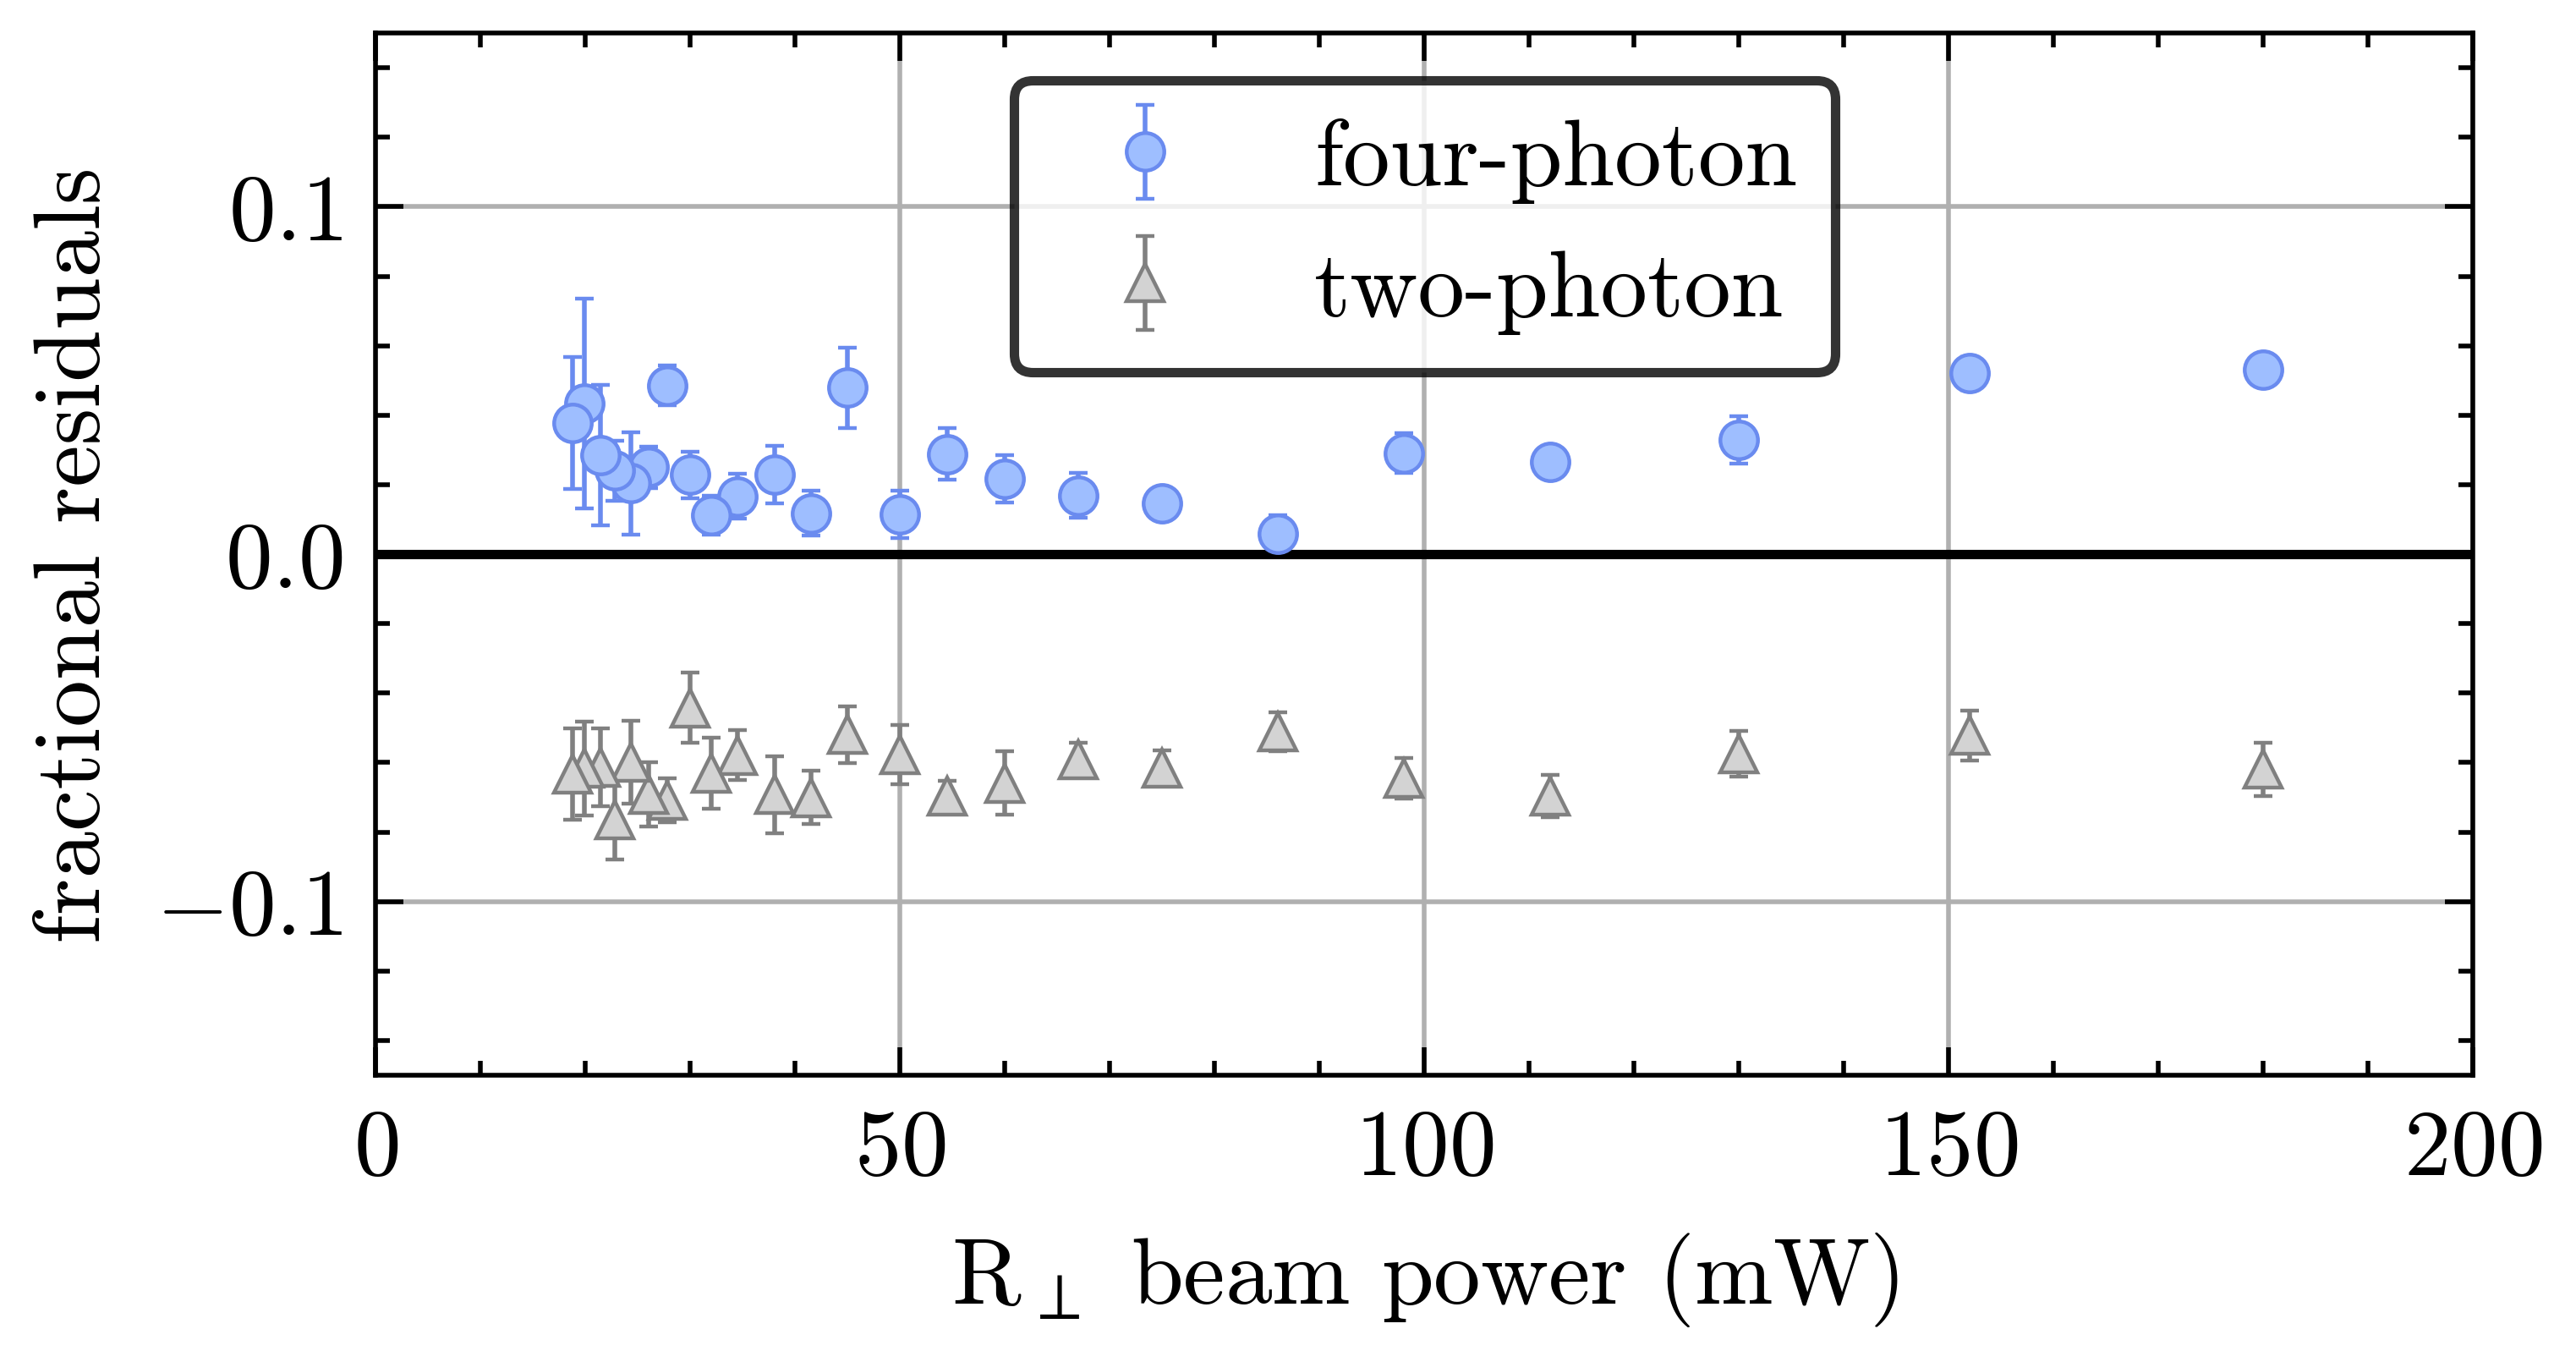

In [23]:
with plt.style.context(['science','no-latex']):
    plt.figure(dpi = 800, figsize = (4,2))

    plt.errorbar(x_data*1e3,((np.pi/sim_d52.tpi_4)/(2*np.pi*1e3) - y[-24:])/((np.pi/sim_d52.tpi_4)/(2*np.pi*1e3)), 
                 ((np.pi*sim_d52.δtpi_4/sim_d52.tpi_4**2)/(2*np.pi*1e3))/((np.pi/sim_d52.tpi_4)/(2*np.pi*1e3)), marker = '.' , ls = 'none', ecolor = cb_d, markeredgecolor = cb_d, markeredgewidth = .4, 
                 markersize=8, capsize=1, elinewidth = .5,markerfacecolor=cb_l, alpha = 1, label = 'four-photon')
    plt.errorbar(x_data*1e3,((np.pi/sim_d52.tpi_2)/(2*np.pi*1e3) - y[0:24])/((np.pi/sim_d52.tpi_2)/(2*np.pi*1e3) ), 
                ( (np.pi*sim_d52.δtpi_2/sim_d52.tpi_2**2)/(2*np.pi*1e3))/((np.pi/sim_d52.tpi_2)/(2*np.pi*1e3) ),marker = '^' , ls = 'none', ecolor = 'grey', markeredgecolor = 'grey', markeredgewidth = .4, 
                 markersize=4, capsize=1, elinewidth = .5,markerfacecolor='lightgray', alpha = 1, label = 'two-photon')
    
#     plt.plot(x*1e3,y[-24:],label = 'full simulation fit', color = cb_l)
    
    
    plt.axhline(0, color = 'black')
    plt.xlim(0,200)
    plt.ylim(-.15, 0.15)
    plt.grid()
    plt.legend(frameon = True, edgecolor = 'black')
    plt.ylabel('fractional residuals')
    plt.xlabel(r'R$_\perp$ beam power (mW)')
    # plt.title(r'$+5/2 \leftrightarrow -1/2$ Rabi frequency')
    plt.show()

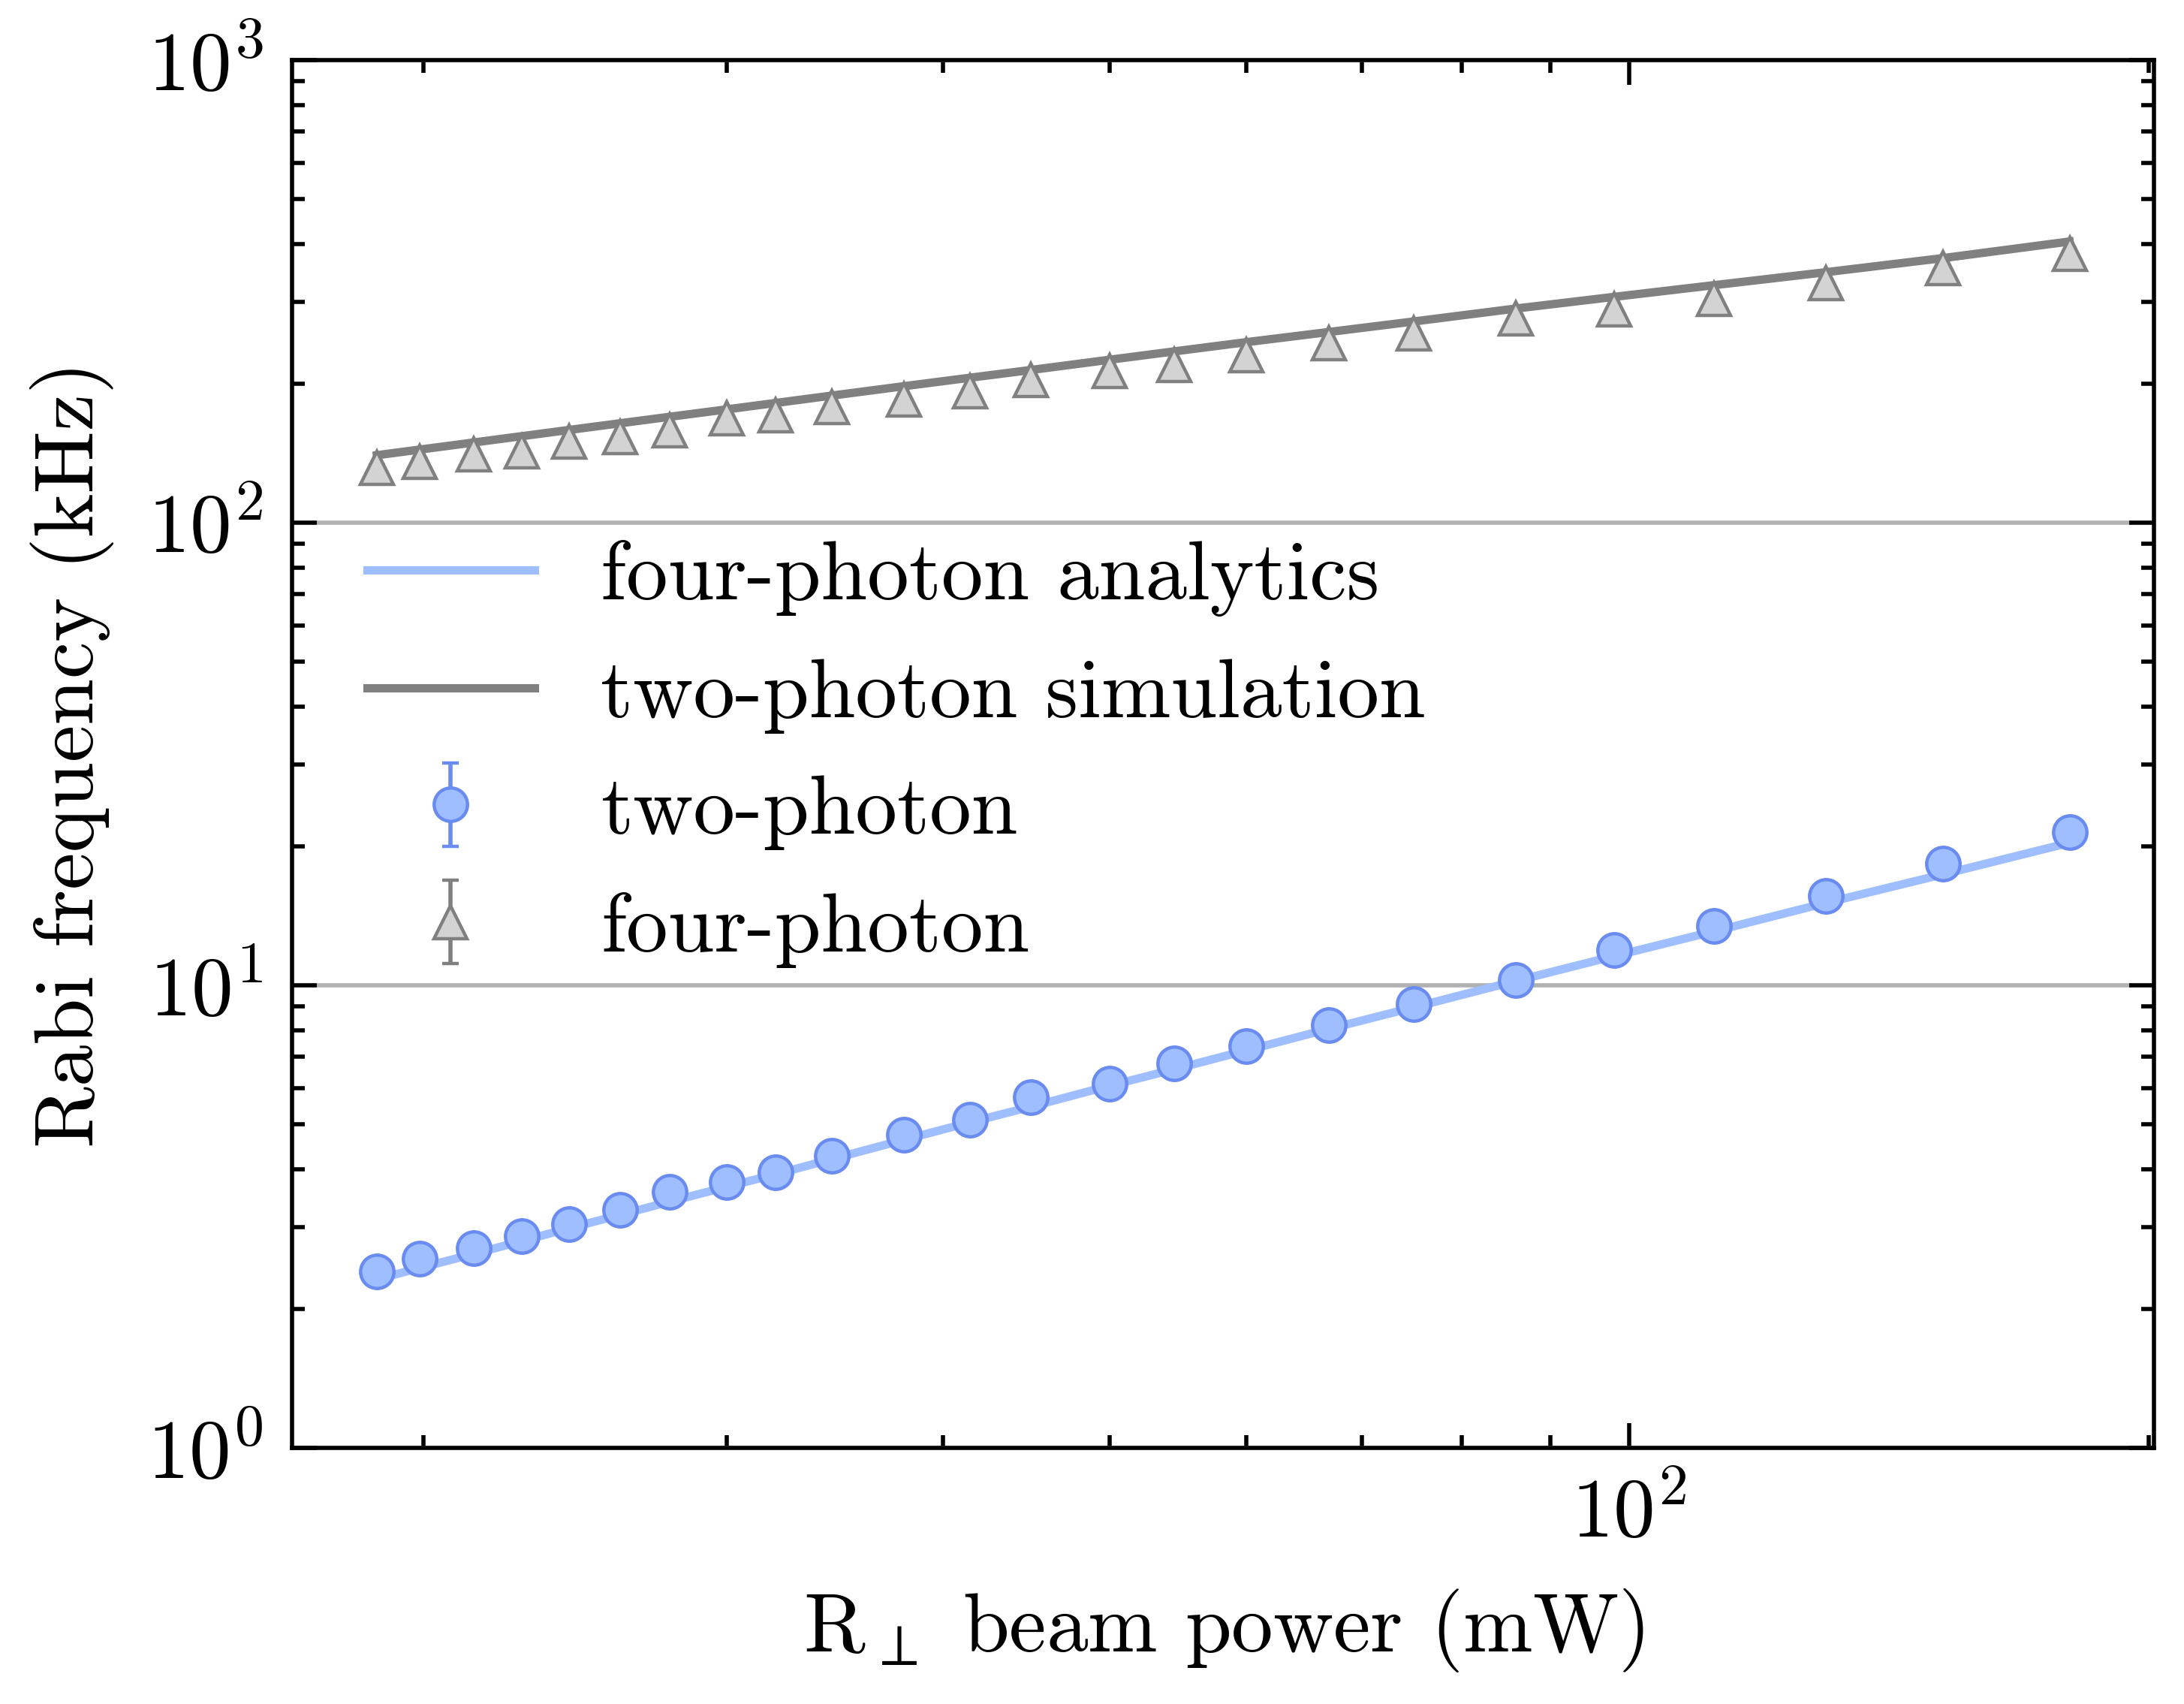

In [24]:
with plt.style.context(['science','no-latex']):
    plt.figure(dpi = 800, figsize = (4,3))

#     plt.errorbar(x_data*1e3,(np.pi/sim_d52.tpi_4)/(2*np.pi*1e3), 
#                  (np.pi*sim_d52.δtpi_4/sim_d52.tpi_4**2)/(2*np.pi*1e3), marker = '.' , ls = 'none', ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .4, 
#                  markersize=5, capsize=1, elinewidth = .5,markerfacecolor=cb_l, alpha = 1)
    
    plt.errorbar(x_data*1e3,(np.pi/sim_d52.tpi_4)/(2*np.pi*1e3), 
                 (np.pi*sim_d52.δtpi_4/sim_d52.tpi_4**2)/(2*np.pi*1e3), marker = '.' , ls = 'none', ecolor = cb_d, markeredgecolor = cb_d, markeredgewidth = .4, 
                 markersize=8, capsize=1, elinewidth = .5,markerfacecolor=cb_l, alpha = 1, label = 'two-photon')
    
    plt.plot(x*1e3,y[-24:],label = 'four-photon analytics', color = cb_l)
    
#     plt.errorbar(x_data*1e3,(np.pi/sim_d52.tpi_2)/(2*np.pi*1e3), 
#              (np.pi*sim_d52.δtpi_2/sim_d52.tpi_2**2)/(2*np.pi*1e3), marker = '.' , ls = 'none', ecolor = 'black', markeredgecolor = 'black', markeredgewidth = .4, 
#              markersize=5, capsize=1, elinewidth = .5,markerfacecolor='gray', label = 'experiment', alpha = 1)
    
    plt.errorbar(x_data*1e3,(np.pi/sim_d52.tpi_2)/(2*np.pi*1e3), 
             (np.pi*sim_d52.δtpi_2/sim_d52.tpi_2**2)/(2*np.pi*1e3),marker = '^' , ls = 'none', ecolor = 'grey', markeredgecolor = 'grey', markeredgewidth = .4, 
                 markersize=4, capsize=1, elinewidth = .5,markerfacecolor='lightgray', alpha = 1, label = 'four-photon')
    
    plt.plot(x*1e3,y[0:24],label = 'two-photon simulation', color = 'grey')
    
    
    plt.axhline(0, color = 'black')
    # plt.xlim(0,200)
    plt.ylim(1e0, 1e3)
    plt.grid(axis = 'y')
    plt.legend()
    plt.ylabel('Rabi frequency (kHz)')
    plt.xlabel(r'R$_\perp$ beam power (mW)')
#     plt.title(r'$+5/2 \leftrightarrow -1/2$ Rabi frequency')
    plt.xscale('log')
    plt.yscale('log')
    plt.show()

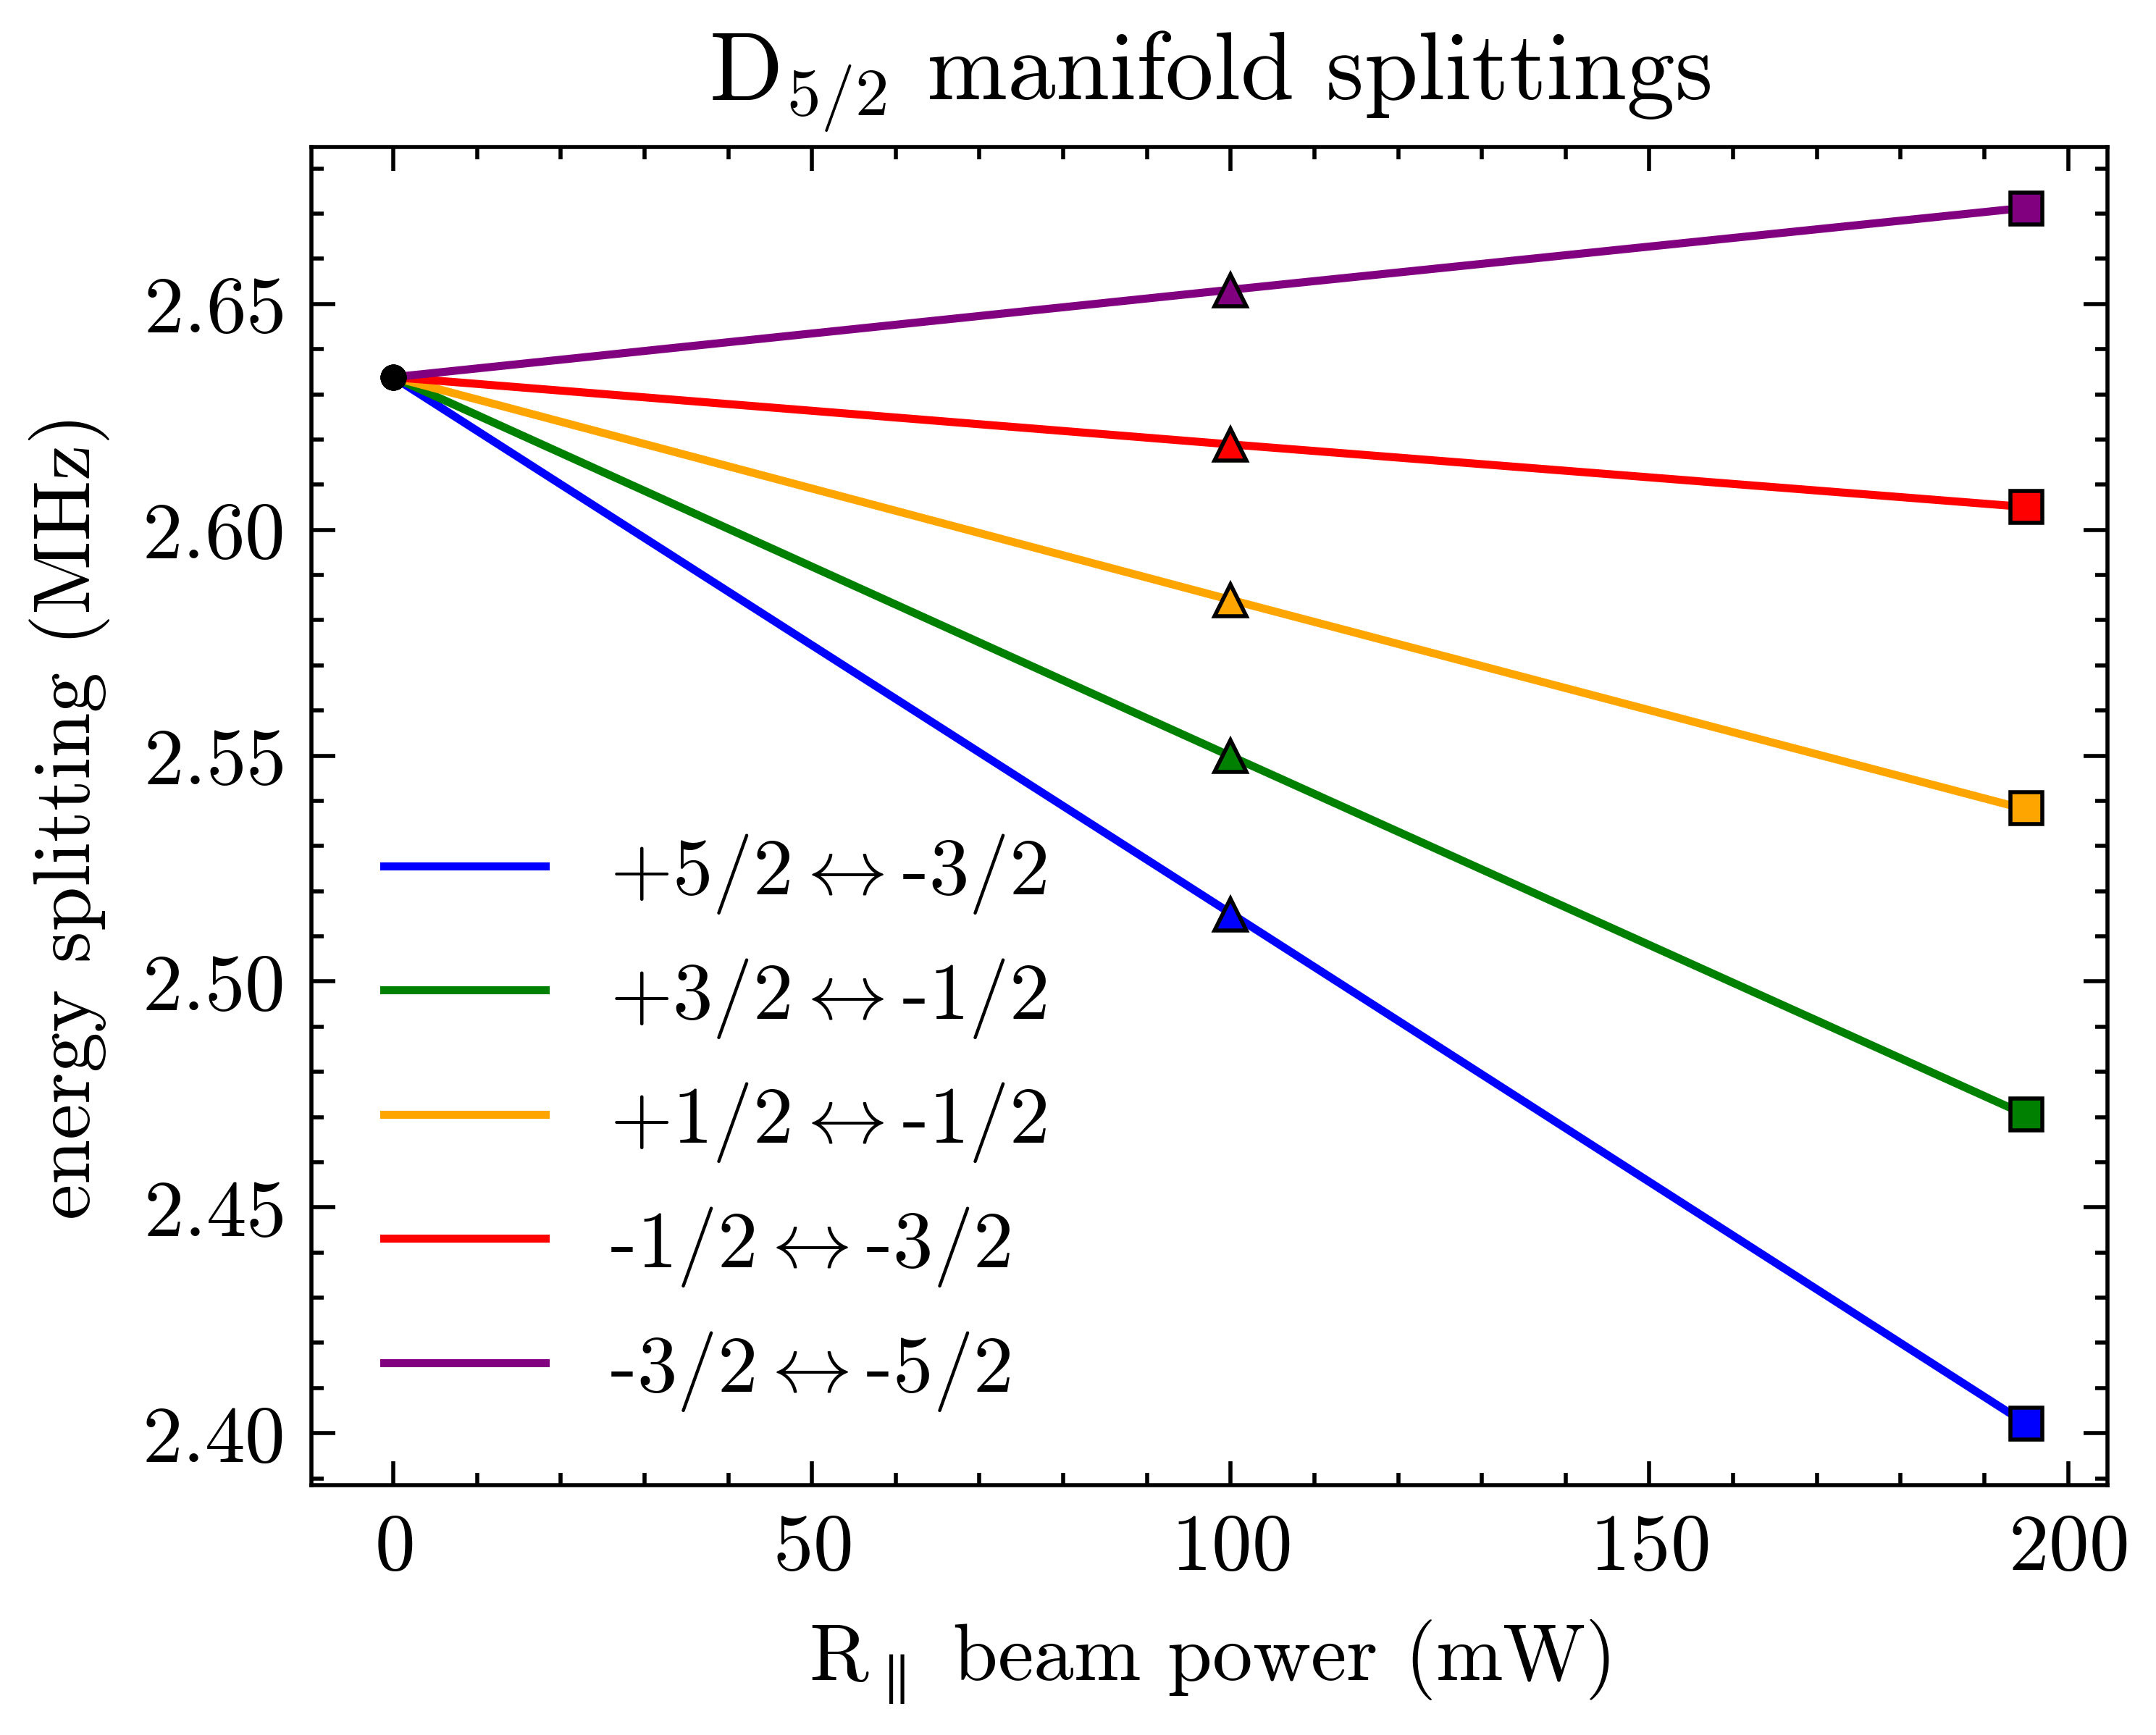

In [25]:
y_data = sim_d52.d52_splittings
δy_data = sim_d52.δd52_splittings

res = y_data - y[24:34]*1e-3
δres = δy_data

y_sim = y[24:34]*1e-3

Pr_bank = np.array([.1, .195])
Pr_bank0 = np.array([0, .1, .195])
colors = ['blue','green','orange','red','purple']
labels =  [r'+5/2$\leftrightarrow$-3/2', r'+3/2$\leftrightarrow$-1/2', r'+1/2$\leftrightarrow$-1/2', r'-1/2$\leftrightarrow$-3/2', r'-3/2$\leftrightarrow$-5/2']
with plt.style.context(['science','no-latex']):
    plt.figure(dpi = 800, figsize = (4,3))
    for i in range(len(colors)):

        plt.plot(Pr_bank0*1e3, [sim_d52.ω0/(2*np.pi*1e6), y_sim[2*i], y_sim[2*i+1]], color = colors[i], label = labels[i])
        plt.scatter([0], [sim_d52.ω0/(2*np.pi*1e6)], color = 'black', s = 5, zorder = 20)
#         plt.scatter(Pr_bank[0]*1e3, y_data[2*i], color = colors[i], edgecolor = 'black', marker = '^')
#         plt.scatter(Pr_bank[1]*1e3, y_data[2*i+1], color = colors[i], edgecolor = 'black', marker = 's')
        
        plt.errorbar(Pr_bank[0]*1e3, y_data[2*i],δy_data[2*i], marker = '^' , ls = 'none',
                     markeredgecolor = 'black', markeredgewidth = .5, markerfacecolor=colors[i],  ecolor = 'black',
                   markersize=4, capsize=1, elinewidth = .5, alpha = 1, zorder = 10)
        plt.errorbar(Pr_bank[1]*1e3, y_data[2*i+1],δy_data[2*i+1], marker = 's' , ls = 'none',
                     markeredgecolor = 'black', markeredgewidth = .5, markerfacecolor=colors[i],  ecolor = 'black',
                   markersize=4, capsize=1, elinewidth = .5, alpha = 1, zorder = 10)

        # plt.scatter(Pr_bank[0]*1e3, y_data[2*i], color = colors[i])
        # plt.scatter(Pr_bank[1]*1e3, y_data[2*i+1], color = colors[i])
        plt.title(r'D$_{5/2}$ manifold splittings')
        plt.xlabel(r'R$_\parallel$ beam power (mW)')
        plt.ylabel('energy splitting (MHz)')
        plt.legend()
    plt.show()

0
0 -0.2275685847670239
1
0 -0.06657736085013966
2
1 0.0023711193817277376
3
1 0.12667419058765006
4
2 -0.01998120839319384
5
2 0.29780934063516895
6
3 -0.0810052701663011
7
3 0.036649222152185246
8
4 -0.18744076801402443
9
4 -0.18150503200198287


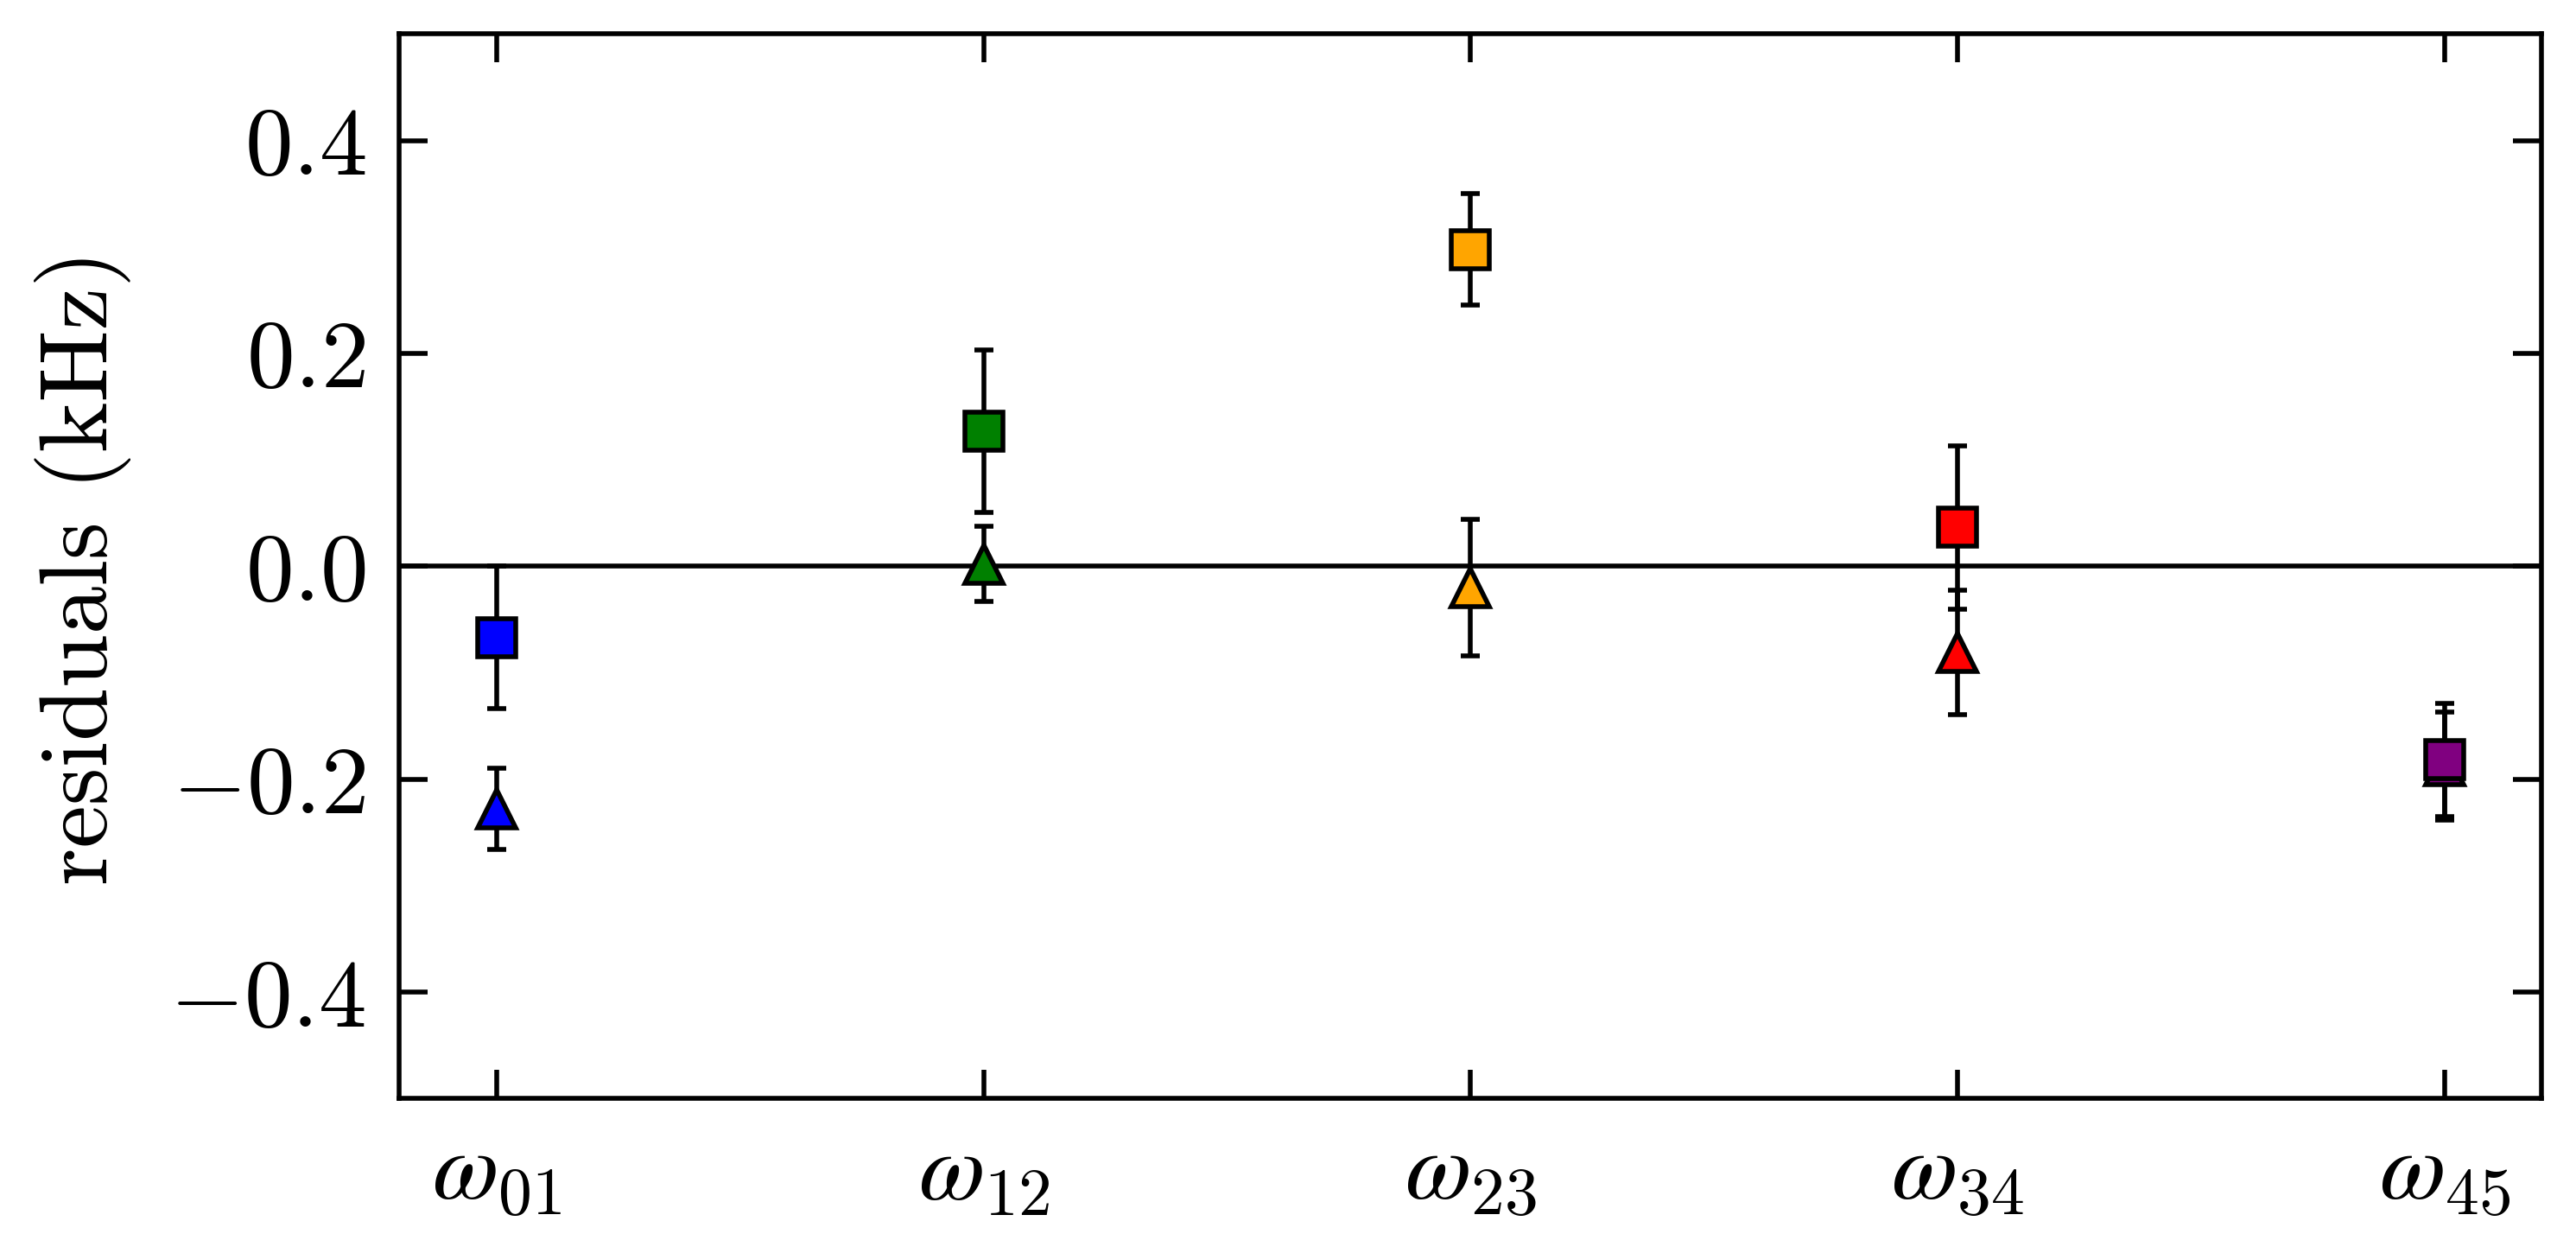

In [26]:
with plt.style.context(['science','no-latex']):
    plt.figure(dpi = 800, figsize = (4,2))
#     plt.errorbar([0,1,2,3,4],res*1e3, δres*1e3, marker = '^' , ls = 'none',
#                  markeredgecolor = 'black', markeredgewidth = .5, markerfacecolor = 'white',  ecolor = 'black',
#                markersize=0, capsize=1, elinewidth = .5, alpha = 1, zorder = 10,label = r'-3/2$\leftrightarrow$-5/2')
    
    xvals = [0,0,1,1,2,2,3,3,4,4]
    colors = ['blue','blue','green','green','orange','orange','red','red','purple','purple']
    ms = ['^','s','^','s','^','s','^','s','^','s']
    for i, c in enumerate(colors):
        print(i)
        # plt.errorbar(
        #     xvals[i], res[i]*1e3,δres[i]*1e3,
        #     marker='^',                    
        #     color=c,
        #     edgecolor='black',
        #     linewidths = .5,# facecolor              
        #     s=15,                            
        #     zorder=11
        # )
        
        plt.errorbar(xvals[i], res[i]*1e3,δres[i]*1e3, marker = ms[i] , ls = 'none',
                     markeredgecolor = 'black', markeredgewidth = .5, markerfacecolor=c,  ecolor = 'black',
                   markersize=4, capsize=1, elinewidth = .5, alpha = 1, zorder = 10,label = r'-3/2$\leftrightarrow$-5/2')
        
        print(xvals[i], res[i]*1e3)    
    plt.xticks([0,1,2,3,4], [r'$ω_{01}$', r'$ω_{12}$', r'$ω_{23}$',r'$ω_{34}$',r'$ω_{45}$'])
    plt.ylabel('residuals (kHz)')
    plt.axhline(0,color = 'black', linewidth = .5)
    #plt.legend()
    plt.ylim(-.5, .5)
    #plt.grid()
    plt.minorticks_off()
    plt.show()

In [10]:
sim_d52 = s.sim()
sim_d52.counter_rot = True
sim_d52.F_states = True
sim_d52.ls_order = 6
sim_d52.get_f()

In [11]:
Pr = np.linspace(0, .2, 5)
sim_d52.rsig_splittings(Pr)

In [15]:
plt.scatter(Pr*1e3, sim_d52.w01/(2*np.pi*1e6))
plt.scatter(Pr*1e3, sim_d52.w12/(2*np.pi*1e6))
plt.scatter(Pr*1e3, sim_d52.w23/(2*np.pi*1e6))
plt.scatter(Pr*1e3, sim_d52.w34/(2*np.pi*1e6))
plt.scatter(Pr*1e3, sim_d52.w45/(2*np.pi*1e6))
plt.show()

NameError: name 'Pr' is not defined

In [26]:
xvals

[0, 0, 1, 1, 2, 2, 3, 3, 4, 4]

In [6]:
sim_d52.d52_splittings*1e3

array([2514.87242, 2402.04469, 2549.89117, 2470.5837 , 2584.4747 ,
       2538.40501, 2618.83663, 2605.09844, 2652.97022, 2671.13929])

In [16]:
sim_d52.w01/(2*np.pi*1e6)

array([2.51542638, 2.40277968])

In [17]:
sim_d52.w12/(2*np.pi*1e6)

array([2.54987226, 2.47044836])

In [18]:
sim_d52.w23/(2*np.pi*1e6)

array([2.58447967, 2.53809138])